# 1.2 basic: Evaluation metrics
**Responsible:** _(Aldo Patrone)_

Three metrics from optimization/metrics.py (average cycle time, resource occupation as busy / available, weighted resource fairness as Gini) validated against the real BPIC-17 log for reference values.

These metrics double as the reward signal for the RL policy (2.4_rl_allocation, D). They are also the basis for the overall cross-method comparison (task F, 2.7_evaluation). The compare_on_sim hook at the end feeds the integrated simulator output into the same metrics once available.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from resources.availability import AvailabilityModel
from optimization import metrics, compute_all

log = load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet')
dur = metrics.activity_durations(log)
print(len(log), 'events,', log['org:resource'].nunique(), 'resources,', log['case:concept:name'].nunique(), 'cases')

1202267 events, 149 resources, 31509 cases


## 1. Average cycle time

mean 21.9 days | median 19.1 days | 31509 cases


saved ../results/metric_cycle_time.png


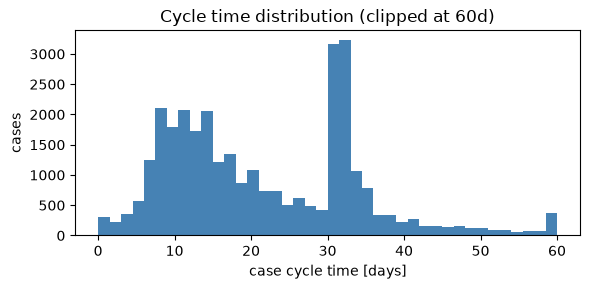

In [2]:
ts = pd.to_datetime(log['time:timestamp'], utc=True)
g = pd.DataFrame({'case': log['case:concept:name'].values, 'ts': ts.values}).groupby('case')['ts']
cycle_days = ((g.max() - g.min()).dt.total_seconds() / 86400)
ct = metrics.average_cycle_time(log)
print('mean %.1f days | median %.1f days | %d cases' % (ct['mean_days'], cycle_days.median(), ct['n_cases']))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(cycle_days.clip(upper=60), bins=40, color='steelblue')
ax.set_xlabel('case cycle time [days]'); ax.set_ylabel('cases'); ax.set_title('Cycle time distribution (clipped at 60d)')
fig.tight_layout(); fig.savefig('../results/metric_cycle_time.png', dpi=120)
print('saved ../results/metric_cycle_time.png')

## 2. Average resource occupation
Busy time uses the **union of busy intervals**, so overlapping waiting work items are not double-counted. A resumed activity is timed from its resume event, so the suspend and resume transitions the simulator emits are handled. Two denominators: the total log window vs. each resource's available time from the learned availability calendars (more meaningful, reuses the availability model).

occupation | total-window: mean 0.270  | availability-based: mean 0.963 (mode=advanced)
saved ../results/metric_occupation.png


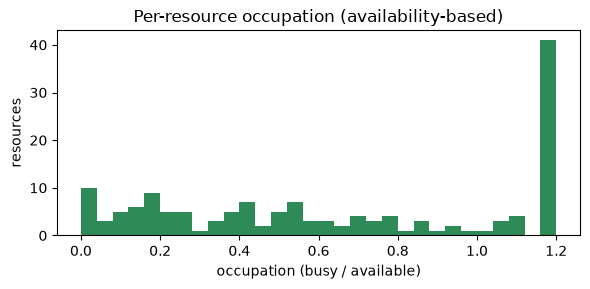

In [3]:
av = AvailabilityModel(log, artifact_path='../results/availability_calendars.json')
occ_win = metrics.average_resource_occupation(log)
occ_av = metrics.average_resource_occupation(log, availability=av)
print('occupation | total-window: mean %.3f  | availability-based: mean %.3f (mode=%s)' % (
    occ_win['mean'], occ_av['mean'], av.mode))

vals = np.array(list(occ_av['per_resource'].values()))
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(np.clip(vals, 0, 1.2), bins=30, color='seagreen')
ax.set_xlabel('occupation (busy / available)'); ax.set_ylabel('resources'); ax.set_title('Per-resource occupation (availability-based)')
fig.tight_layout(); fig.savefig('../results/metric_occupation.png', dpi=120)
print('saved ../results/metric_occupation.png')

## 3. (weighted) resource fairness
Gini coefficient over per-resource busy time (0 = everyone carries an equal load, higher = more unequal). The weighted variant normalizes by availability (fairness of *utilization* rather than raw load).

In [4]:
fair_busy = metrics.resource_fairness(log, by='busy')
fair_count = metrics.resource_fairness(log, by='count')
fair_weighted = metrics.resource_fairness(log, weighted=True, availability=av)
print('Gini | by busy-time: %.3f | by activity-count: %.3f | weighted (utilization): %.3f' % (
    fair_busy['gini'], fair_count['gini'], fair_weighted['gini']))

Gini | by busy-time: 0.514 | by activity-count: 0.508 | weighted (utilization): 0.530


## Reference summary

In [5]:
summary = pd.DataFrame([
    ['avg cycle time [days]', round(ct['mean_days'], 1)],
    ['avg occupation (total-window)', round(occ_win['mean'], 3)],
    ['avg occupation (availability)', round(occ_av['mean'], 3)],
    ['fairness Gini (busy)', round(fair_busy['gini'], 3)],
    ['fairness Gini (weighted)', round(fair_weighted['gini'], 3)],
], columns=['metric', 'real BPIC-17'])
summary.to_csv('../results/metrics_reference.csv', index=False)
print(summary.to_string(index=False))
print('\nsaved ../results/metrics_reference.csv')

                       metric  real BPIC-17
        avg cycle time [days]        21.900
avg occupation (total-window)         0.270
avg occupation (availability)         0.963
         fairness Gini (busy)         0.514
     fairness Gini (weighted)         0.530

saved ../results/metrics_reference.csv


**These are reference values on the real log.** The same *compute_all* runs on the simulator output to provide the scalar reward for training the RL policy (*2.4_rl_allocation*, D) and to drive the overall cross-method comparison (task F, *2.7_evaluation*) via the *compare_on_sim* hook below.

### Integration hook for task F
compare_on_sim (now canonical in optimization/metrics.py) is the bridge to the overall evaluation (task F, 2.7_evaluation). scripts/compare_on_sim.py runs the integrated simulator once per allocation strategy (incl. the RL policy from 2.4_rl_allocation) and feeds the per-method output logs through it, giving the cross-method comparison on the real simulator (cycle time / occupation / fairness).

In [6]:
from optimization.metrics import compare_on_sim
sim = pd.read_csv('../results/sim_comparison.csv')
print('cross-method comparison on the integrated simulator (real arrival load):')
print(sim.to_string(index=False))

cross-method comparison on the integrated simulator (real arrival load):
           method  cycle_time_days  occupation  fairness_gini
           random              0.3       0.091          0.799
   shortest-queue              0.3       0.271          0.761
 most-experienced              0.3       0.072          0.843
   RL (REINFORCE)              0.4       0.091          0.825
PPO (MaskablePPO)              0.3       0.075          0.774
